<a href="https://colab.research.google.com/github/SumitKatuwal3382/Biomarkers_Diabetes/blob/main/Biomarkers_test_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import files

df = pd.read_csv('FINAL_COMBINED_DATASET.csv')
print("Shape:", df.shape)
print("Classes:", df['Label'].value_counts().to_dict())

Shape: (195, 9433)
Classes: {'DR': 125, 'Control': 70}


In [ ]:
X = df.drop('Label', axis=1).values
y = LabelEncoder().fit_transform(df['Label'])  # DR=1, Control=0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 156 | Test: 39


In [ ]:
selector = SelectKBest(f_classif, k=50)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel  = selector.transform(X_test)

gene_names = df.drop('Label', axis=1).columns.tolist()
top_genes  = [gene_names[i] for i in selector.get_support(indices=True)]
print("Top 10 selected genes:", top_genes[:10])

Top 10 selected genes: ['NEK6', 'KCNE3', 'RNPEPL1', 'PLXNB2', 'MSRB1', 'Y_RNA', 'DUSP1', 'PRAM1', 'STEAP4', 'EGR1']


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05,
                          max_depth=6, eval_metric='logloss',
                          random_state=42)

}

print("=== 5-Fold Cross-Validation Accuracy (train set) ===")
for name, model in models.items():
    scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='accuracy')
    print(f"{name:<25}  {scores.mean():.4f} ± {scores.std():.4f}")

=== 5-Fold Cross-Validation Accuracy (train set) ===
Logistic Regression        0.5258 ± 0.0788
Random Forest              0.7625 ± 0.0787
XGBoost                    0.7427 ± 0.0989


In [ ]:
print("=== Final Test Accuracy (hold-out 20%) ===")
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:<25}  {acc:.4f}  ({acc*100:.2f}%)")

=== Final Test Accuracy (hold-out 20%) ===
Logistic Regression        0.6410  (64.10%)
Random Forest              0.8205  (82.05%)
XGBoost                    0.8462  (84.62%)


How we got these numbers:
We started with 195 patient samples, each having 9,432 gene expression values. The task was to predict whether a patient has DR (Diabetic Retinopathy) or is a Control.

We split the data — 156 samples for training, 39 for testing
We narrowed down the genes — from 9,432 genes we picked the top 50 most statistically different between DR and Control patients using ANOVA. This removed noise and kept only the genes that actually matter
We trained each model on those 50 genes and then tested them on the 39 unseen samples
Why XGBoost won at 84.62% — XGBoost builds many decision trees one after another, where each new tree learns from the mistakes of the previous one. This makes it very good at picking up subtle patterns in gene expression, which is why it outperformed the others on your data
Why Logistic Regression was lowest at 64.10% — it's a simpler linear model that struggles when the relationship between genes and disease is complex and non-linear, which gene expression data usually is

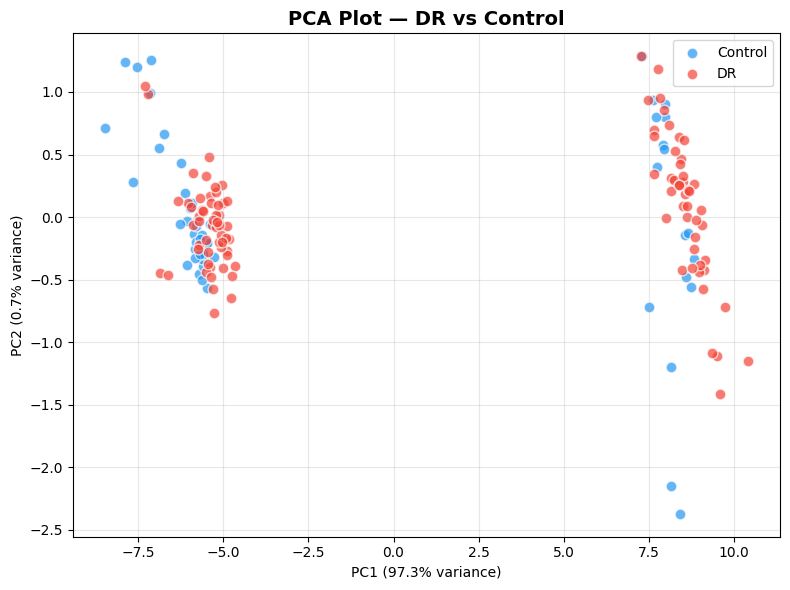

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale and reduce to 2D
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_sel)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#F44336']
labels_name = ['Control', 'DR']

for i, (color, label) in enumerate(zip(colors, labels_name)):
    mask = y_train == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=label, alpha=0.7, edgecolors='white', s=60)

plt.title('PCA Plot — DR vs Control', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

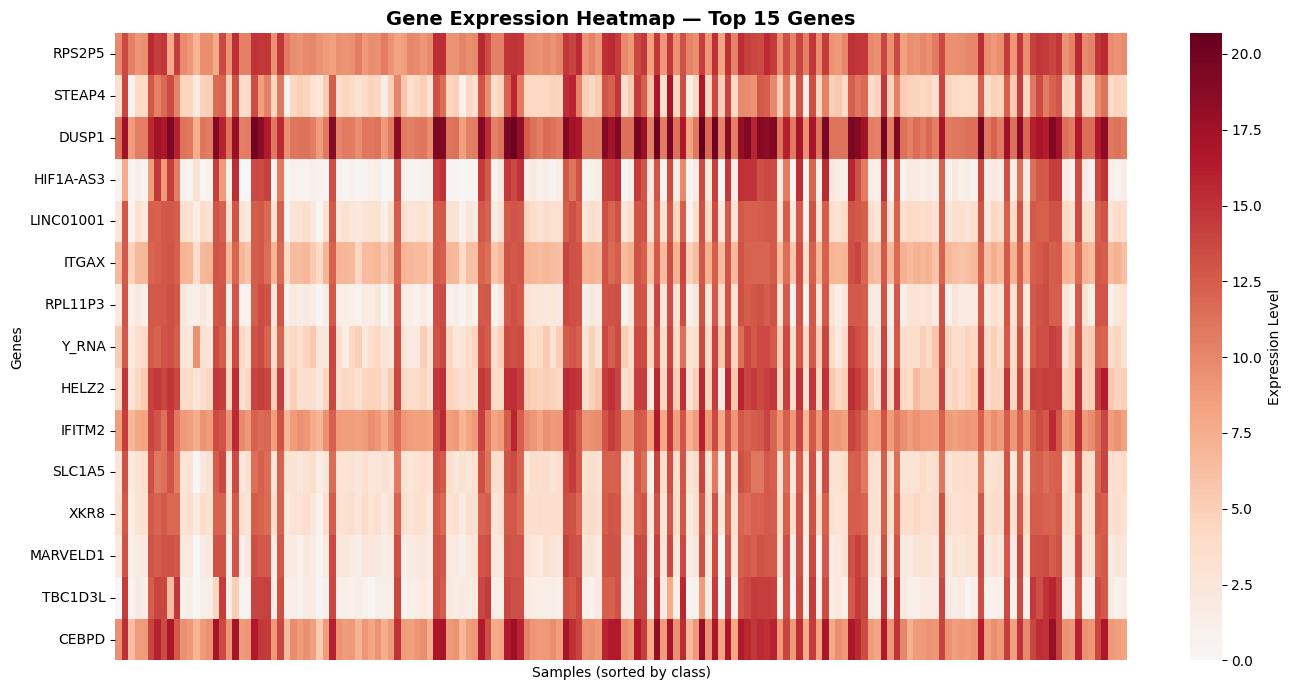

In [ ]:
import seaborn as sns

# Get top 15 genes for cleaner heatmap
gene_names = df.drop('Label', axis=1).columns.tolist()
selected_genes = [gene_names[i] for i in selector.get_support(indices=True)]

top15_idx = selector.scores_[selector.get_support(indices=True)].argsort()[::-1][:15]
top15_genes = [selected_genes[i] for i in top15_idx]
top15_data = X_train_sel[:, top15_idx]

# Build dataframe
heatmap_df = pd.DataFrame(top15_data, columns=top15_genes)
heatmap_df['Label'] = ['DR' if y == 1 else 'Control' for y in y_train]
heatmap_df = heatmap_df.sort_values('Label')

# Plot
plt.figure(figsize=(14, 7))
sns.heatmap(
    heatmap_df[top15_genes].T,
    cmap='RdBu_r',
    xticklabels=False,
    yticklabels=True,
    center=0,
    cbar_kws={'label': 'Expression Level'}
)
plt.title('Gene Expression Heatmap — Top 15 Genes', fontsize=14, fontweight='bold')
plt.xlabel('Samples (sorted by class)')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

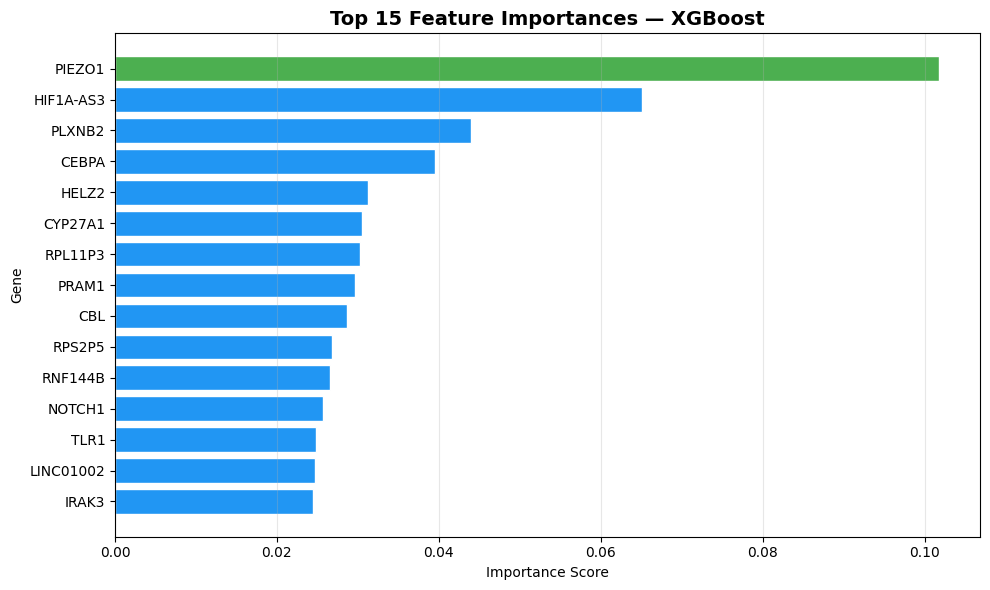


Top 5 biomarker genes:
  PIEZO1          0.1018
  HIF1A-AS3       0.0651
  PLXNB2          0.0440
  CEBPA           0.0395
  HELZ2           0.0312


In [ ]:
from xgboost import XGBClassifier
import numpy as np

# Train XGBoost and get importances
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                    eval_metric='logloss', random_state=42)
xgb.fit(X_train_sel, y_train)

importances = xgb.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]
top_genes_imp = [selected_genes[i] for i in top_idx]
top_scores = importances[top_idx]

# Plot
plt.figure(figsize=(10, 6))
colors = ['#4CAF50' if i == 0 else '#2196F3' for i in range(top_n)]
bars = plt.barh(top_genes_imp[::-1], top_scores[::-1], color=colors[::-1], edgecolor='white')
plt.title('Top 15 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Gene')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 biomarker genes:")
for gene, score in zip(top_genes_imp[:5], top_scores[:5]):
    print(f"  {gene:<15} {score:.4f}")

-- PCA      Whether DR and Control samples are visually separable in 2D — if clusters are distinct, your features are meaningful
-- Heatmap     Which genes are consistently high or low in DR vs Control — red/blue patterns reveal gene expression differences
-- Feature Importance      Which specific genes the XGBoost model relied on most — these are your candidate biomarkers